Q1. Missing values count:
Age             2
Salary          2
City            2
Joined_Date     0
Empty_Col      12
dtype: int64

------------------------------

Q2. Percentage of missing values:
Age             16.666667
Salary          16.666667
City            16.666667
Joined_Date      0.000000
Empty_Col      100.000000
dtype: float64

------------------------------

Q3. Shape after dropping rows with missing values: (0, 5)

------------------------------

Q4. Columns left after dropping >50% missing cols: ['Age', 'Salary', 'City', 'Joined_Date']

------------------------------

Q5. Age filled with Mean:
[ 25.   30.   47.5  35.   40.  200.   22.   47.5  28.   32.   18.   45. ]

------------------------------

Q6. Age filled with Median:
[ 25.  30.  31.  35.  40. 200.  22.  31.  28.  32.  18.  45.]

------------------------------

Q7. City filled with Mode:
<StringArray>
[    'Delhi',    'Mumbai',     'Delhi',     'Delhi', 'Bangalore',    'Mumbai',
     'Delhi', 'Bangalore',     'De

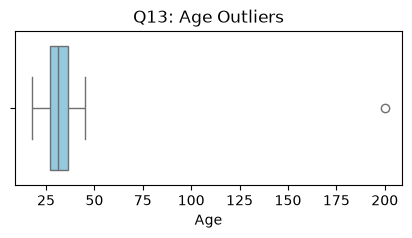

Q14. Displaying Scatter Plot for Age...


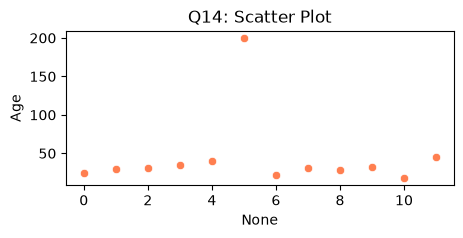

Q15. Shape after removing outliers: (11, 4)

------------------------------

Q16. Age values after replacing outliers with median:
[25. 30. 31. 35. 40. 31. 22. 31. 28. 32. 18. 45.]

------------------------------

Q17. Age values after percentile capping:
[ 25.    30.    31.    35.    40.   114.75  22.    31.    28.    32.
  20.2   45.  ]

------------------------------

Q18. Stats before vs after capping:
           Before       After
count   12.000000   12.000000
mean    44.750000   37.829167
std     49.435219   25.211924
min     18.000000   20.200000
25%     27.250000   27.250000
50%     31.000000   31.000000
75%     36.250000   36.250000
max    200.000000  114.750000

------------------------------

Q19. Min-Max Scaled head:
        Age    Salary
0  0.050767  0.007937
1  0.103649  0.047619
2  0.114225  0.027778

------------------------------

Q20. Standardized head:
        Age    Salary
0 -0.531480 -0.473709
1 -0.324342 -0.326823
2 -0.282915 -0.400266

---------------------------

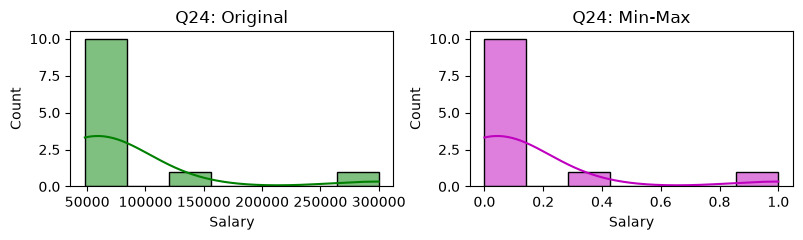

Q25. Displaying Boxplot Comparison...


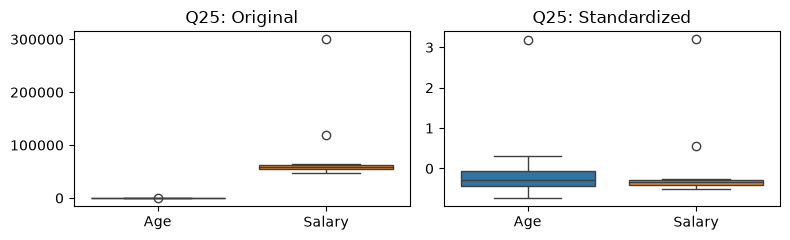

Q26. All Scalers comparison on Salary:
       Raw    MinMax       Std    Robust
0  50000.0  0.007937 -0.473709 -1.090909
1  60000.0  0.047619 -0.326823  0.121212
2  55000.0  0.027778 -0.400266 -0.484848

------------------------------

Q27. Label Encoded City:
     City  City_Code
0   Delhi          1
1  Mumbai          2
2   Delhi          1

------------------------------

Q28. One-hot Encoded dummy columns:
['City_Code', 'City_Bangalore', 'City_Delhi', 'City_Mumbai']

------------------------------

Q29. Binary Encoded City:
   City_Code City_Bin
0          1       01
1          2       10
2          1       01

------------------------------

Q30. Created Salary_per_Age feature:
    Salary   Age  Salary_per_Age
0  50000.0  25.0     2000.000000
1  60000.0  30.0     2000.000000
2  55000.0  31.0     1774.193548

------------------------------

Q31. Extracted Year, Month, Day:
  Joined_Date  Year  Month  Day
0  2021-01-15  2021      1   15
1  2020-05-20  2020      5   20
2  2019-11-02 

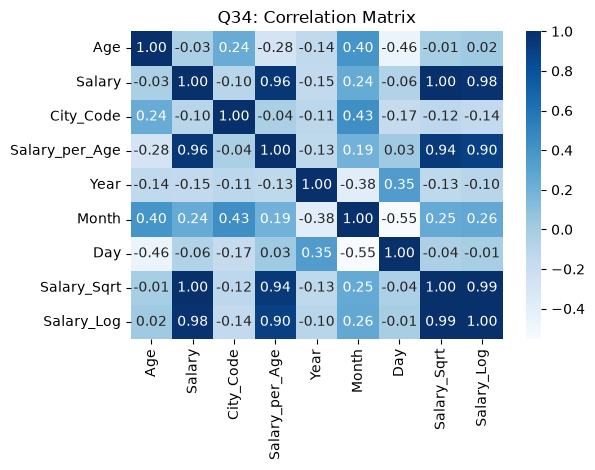

Q35. Final processed dataset saved to CSV. Sample data:
    Age  Year  Month  Salary_Log
0  25.0  2021      1   10.819798
1  30.0  2020      5   11.002117
2  31.0  2019     11   10.915107


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, LabelEncoder

# Data Setup
np.random.seed(42)
raw_data = {
    'Age': [25, 30, np.nan, 35, 40, 200, 22, np.nan, 28, 32, 18, 45],
    'Salary': [50000, 60000, 55000, np.nan, 120000, 62000, 48000, 52000, 58000, 300000, np.nan, 64000],
    'City': ['Delhi', 'Mumbai', 'Delhi', np.nan, 'Bangalore', 'Mumbai', 'Delhi', 'Bangalore', np.nan, 'Delhi', 'Mumbai', 'Bangalore'],
    'Joined_Date': ['2021-01-15', '2020-05-20', '2019-11-02', '2022-03-10', '2021-07-25', '2020-12-01', 
                    '2021-08-18', '2019-02-14', '2022-01-30', '2020-09-09', '2021-11-11', '2022-05-05'],
    'Empty_Col': [np.nan] * 12
}

data = pd.DataFrame(raw_data)
data['Joined_Date'] = pd.to_datetime(data['Joined_Date'])

# Q1
print("Q1. Missing values count:")
print(data.isnull().sum())
print("\n" + "-"*30 + "\n")

# Q2
print("Q2. Percentage of missing values:")
print((data.isnull().sum() / len(data)) * 100)
print("\n" + "-"*30 + "\n")

# Q3
clean_rows = data.dropna()
print("Q3. Shape after dropping rows with missing values:", clean_rows.shape)
print("\n" + "-"*30 + "\n")

# Q4
half_len = 0.5 * len(data)
clean_cols = data.dropna(thresh=len(data) - half_len, axis=1)
print("Q4. Columns left after dropping >50% missing cols:", clean_cols.columns.tolist())
print("\n" + "-"*30 + "\n")

# Q5
df_mean = data.copy()
df_mean['Age'] = df_mean['Age'].fillna(df_mean['Age'].mean())
print("Q5. Age filled with Mean:")
print(df_mean['Age'].values)
print("\n" + "-"*30 + "\n")

# Q6
df_median = data.copy()
df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())
print("Q6. Age filled with Median:")
print(df_median['Age'].values)
print("\n" + "-"*30 + "\n")

# Q7
df_mode = data.copy()
df_mode['City'] = df_mode['City'].fillna(df_mode['City'].mode()[0])
print("Q7. City filled with Mode:")
print(df_mode['City'].values)
print("\n" + "-"*30 + "\n")

# Q8
df_ffill = data.ffill()
print("Q8. Forward fill result on Age:")
print(df_ffill['Age'].values)
print("\n" + "-"*30 + "\n")

# Q9
df_bfill = data.bfill()
print("Q9. Backward fill result on Age:")
print(df_bfill['Age'].values)
print("\n" + "-"*30 + "\n")

# Q10
clean_df = data.copy()
clean_df['Age'] = clean_df['Age'].fillna(clean_df['Age'].median())
clean_df['Salary'] = clean_df['Salary'].fillna(clean_df['Salary'].median())
clean_df['City'] = clean_df['City'].fillna(clean_df['City'].mode()[0])
clean_df = clean_df.drop(columns=['Empty_Col'])
print("Q10. Missing counts before vs after cleaning:")
print(pd.DataFrame({'Original': data.isnull().sum(), 'Imputed': clean_df.isnull().sum()}))
print("\n" + "-"*30 + "\n")

# Q11
q1 = clean_df['Age'].quantile(0.25)
q3 = clean_df['Age'].quantile(0.75)
iqr = q3 - q1
outliers = clean_df[(clean_df['Age'] < (q1 - 1.5 * iqr)) | (clean_df['Age'] > (q3 + 1.5 * iqr))]
print("Q11. Outliers using IQR:")
print(outliers[['Age']])
print("\n" + "-"*30 + "\n")

# Q12
z = np.abs(stats.zscore(clean_df['Age']))
print("Q12. Outliers using Z-score (>2):")
print(clean_df[z > 2][['Age']])
print("\n" + "-"*30 + "\n")

# Q13
print("Q13. Displaying Boxplot for Age Outliers...")
plt.figure(figsize=(5, 2))
sns.boxplot(x=clean_df['Age'], color='skyblue')
plt.title("Q13: Age Outliers")
plt.show()

# Q14
print("Q14. Displaying Scatter Plot for Age...")
plt.figure(figsize=(5, 2))
sns.scatterplot(x=clean_df.index, y=clean_df['Age'], color='coral')
plt.title("Q14: Scatter Plot")
plt.show()

# Q15
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
no_outliers_df = clean_df[(clean_df['Age'] >= lower_bound) & (clean_df['Age'] <= upper_bound)]
print("Q15. Shape after removing outliers:", no_outliers_df.shape)
print("\n" + "-"*30 + "\n")

# Q16
df_rep = clean_df.copy()
df_rep.loc[(df_rep['Age'] < lower_bound) | (df_rep['Age'] > upper_bound), 'Age'] = df_rep['Age'].median()
print("Q16. Age values after replacing outliers with median:")
print(df_rep['Age'].values)
print("\n" + "-"*30 + "\n")

# Q17
df_cap = clean_df.copy()
p_low, p_high = df_cap['Age'].quantile(0.05), df_cap['Age'].quantile(0.95)
df_cap['Age'] = np.clip(df_cap['Age'], p_low, p_high)
print("Q17. Age values after percentile capping:")
print(df_cap['Age'].values)
print("\n" + "-"*30 + "\n")

# Q18
print("Q18. Stats before vs after capping:")
print(pd.DataFrame({'Before': clean_df['Age'].describe(), 'After': df_cap['Age'].describe()}))
print("\n" + "-"*30 + "\n")

# Q19
scaler_mm = MinMaxScaler()
df_mm = df_cap.copy()
df_mm[['Age', 'Salary']] = scaler_mm.fit_transform(df_cap[['Age', 'Salary']])
print("Q19. Min-Max Scaled head:")
print(df_mm[['Age', 'Salary']].head(3))
print("\n" + "-"*30 + "\n")

# Q20
scaler_std = StandardScaler()
df_std = df_cap.copy()
df_std[['Age', 'Salary']] = scaler_std.fit_transform(df_cap[['Age', 'Salary']])
print("Q20. Standardized head:")
print(df_std[['Age', 'Salary']].head(3))
print("\n" + "-"*30 + "\n")

# Q21
scaler_rob = RobustScaler()
df_rob = df_cap.copy()
df_rob[['Age', 'Salary']] = scaler_rob.fit_transform(df_cap[['Age', 'Salary']])
print("Q21. Robust Scaled head:")
print(df_rob[['Age', 'Salary']].head(3))
print("\n" + "-"*30 + "\n")

# Q22
scaler_max = MaxAbsScaler()
df_max = df_cap.copy()
df_max[['Age', 'Salary']] = scaler_max.fit_transform(df_cap[['Age', 'Salary']])
print("Q22. Max Abs Scaled head:")
print(df_max[['Age', 'Salary']].head(3))
print("\n" + "-"*30 + "\n")

# Q23
print("Q23. Comparison of scaling methods:")
print(pd.DataFrame({'Original': df_cap['Age'], 'MinMax': df_mm['Age'], 'Standard': df_std['Age']}).head(3))
print("\n" + "-"*30 + "\n")

# Q24
print("Q24. Displaying Histogram Comparison...")
fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
sns.histplot(df_cap['Salary'], ax=ax[0], color='g', kde=True)
ax[0].set_title("Q24: Original")
sns.histplot(df_mm['Salary'], ax=ax[1], color='m', kde=True)
ax[1].set_title("Q24: Min-Max")
plt.tight_layout()
plt.show()

# Q25
print("Q25. Displaying Boxplot Comparison...")
fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
sns.boxplot(data=df_cap[['Age', 'Salary']], ax=ax[0])
ax[0].set_title("Q25: Original")
sns.boxplot(data=df_std[['Age', 'Salary']], ax=ax[1])
ax[1].set_title("Q25: Standardized")
plt.tight_layout()
plt.show()

# Q26
print("Q26. All Scalers comparison on Salary:")
print(pd.DataFrame({'Raw': df_cap['Salary'], 'MinMax': df_mm['Salary'], 'Std': df_std['Salary'], 'Robust': df_rob['Salary']}).head(3))
print("\n" + "-"*30 + "\n")

# Q27
le = LabelEncoder()
df_fe = df_cap.copy()
df_fe['City_Code'] = le.fit_transform(df_fe['City'])
print("Q27. Label Encoded City:")
print(df_fe[['City', 'City_Code']].head(3))
print("\n" + "-"*30 + "\n")

# Q28
df_fe = pd.get_dummies(df_fe, columns=['City'], prefix='City', drop_first=False)
print("Q28. One-hot Encoded dummy columns:")
print([c for c in df_fe.columns if 'City_' in c])
print("\n" + "-"*30 + "\n")

# Q29
df_fe['City_Bin'] = df_fe['City_Code'].apply(lambda x: format(x, '02b'))
print("Q29. Binary Encoded City:")
print(df_fe[['City_Code', 'City_Bin']].head(3))
print("\n" + "-"*30 + "\n")

# Q30
df_fe['Salary_per_Age'] = df_fe['Salary'] / df_fe['Age']
print("Q30. Created Salary_per_Age feature:")
print(df_fe[['Salary', 'Age', 'Salary_per_Age']].head(3))
print("\n" + "-"*30 + "\n")

# Q31
df_fe['Year'] = df_fe['Joined_Date'].dt.year
df_fe['Month'] = df_fe['Joined_Date'].dt.month
df_fe['Day'] = df_fe['Joined_Date'].dt.day
print("Q31. Extracted Year, Month, Day:")
print(df_fe[['Joined_Date', 'Year', 'Month', 'Day']].head(3))
print("\n" + "-"*30 + "\n")

# Q32
df_fe['Salary_Sqrt'] = np.sqrt(df_fe['Salary'])
print("Q32. Square root transformation:")
print(df_fe[['Salary', 'Salary_Sqrt']].head(3))
print("\n" + "-"*30 + "\n")

# Q33
df_fe['Salary_Log'] = np.log1p(df_fe['Salary'])
print("Q33. Log transformation:")
print(df_fe[['Salary', 'Salary_Log']].head(3))
print("\n" + "-"*30 + "\n")

# Q34
print("Q34. Displaying Correlation Heatmap...")
num_df = df_fe.select_dtypes(include=[np.number])
plt.figure(figsize=(6, 4))
sns.heatmap(num_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title("Q34: Correlation Matrix")
plt.show()

# Q35
final_df = df_fe[['Age', 'Year', 'Month', 'Salary_Log']].copy()
final_df.to_csv("final_preprocessed.csv", index=False)
print("Q35. Final processed dataset saved to CSV. Sample data:")
print(final_df.head(3))